In [1]:
# importing modules

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import silhouette_score, davies_bouldin_score
from scipy.cluster.hierarchy import dendrogram, linkage
import mlflow
import mlflow.sklearn
import warnings
import os
import pickle

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 120

os.makedirs("notebooks/plots/clustering", exist_ok=True)
os.makedirs("src/models", exist_ok=True)

mlflow.set_experiment("PatrolIQ_Clustering")

print("Setup complete. MLflow experiment: PatrolIQ_Clustering")

Setup complete. MLflow experiment: PatrolIQ_Clustering


In [3]:
# loading cleaned data

In [4]:
df = pd.read_parquet("../data/crimes_clean.parquet")
print(f"Loaded: {df.shape}")
print(f"Columns: {list(df.columns)}")

Loaded: (500000, 26)
Columns: ['ID', 'Case Number', 'Date', 'Block', 'IUCR', 'Primary Type', 'Description', 'Location Description', 'Arrest', 'Domestic', 'Beat', 'District', 'Ward', 'Community Area', 'FBI Code', 'X Coordinate', 'Y Coordinate', 'Year', 'Latitude', 'Longitude', 'Hour', 'Day_of_Week', 'Month', 'Is_Weekend', 'Season', 'Crime_Severity_Score']


In [5]:
# Preparing geographic features

In [6]:
geo_df = df[["Latitude", "Longitude", "Crime_Severity_Score",
             "Arrest", "Domestic"]].copy()

geo_df = geo_df.dropna(subset=["Latitude", "Longitude"])

scaler_geo = StandardScaler()
geo_scaled = scaler_geo.fit_transform(
    geo_df[["Latitude", "Longitude"]]
)

print(f"Geographic feature matrix: {geo_scaled.shape}")
print(f"Lat range: {geo_df['Latitude'].min():.4f} → {geo_df['Latitude'].max():.4f}")
print(f"Lon range: {geo_df['Longitude'].min():.4f} → {geo_df['Longitude'].max():.4f}")

pickle.dump(scaler_geo, open("src/models/scaler_geo.pkl", "wb"))
print("Scaler saved.")

Geographic feature matrix: (500000, 2)
Lat range: 41.6446 → 42.0226
Lon range: -87.9289 → -87.5245
Scaler saved.


In [7]:
# Elbow method (find best K)

Running elbow method (K = 2 to 12)... this takes ~2 minutes
  K=2  inertia=464,303
  K=3  inertia=313,698
  K=4  inertia=240,334
  K=5  inertia=196,542
  K=6  inertia=158,481
  K=7  inertia=134,643
  K=8  inertia=116,368
  K=9  inertia=101,553
  K=10  inertia=88,826
  K=11  inertia=81,105
  K=12  inertia=74,025


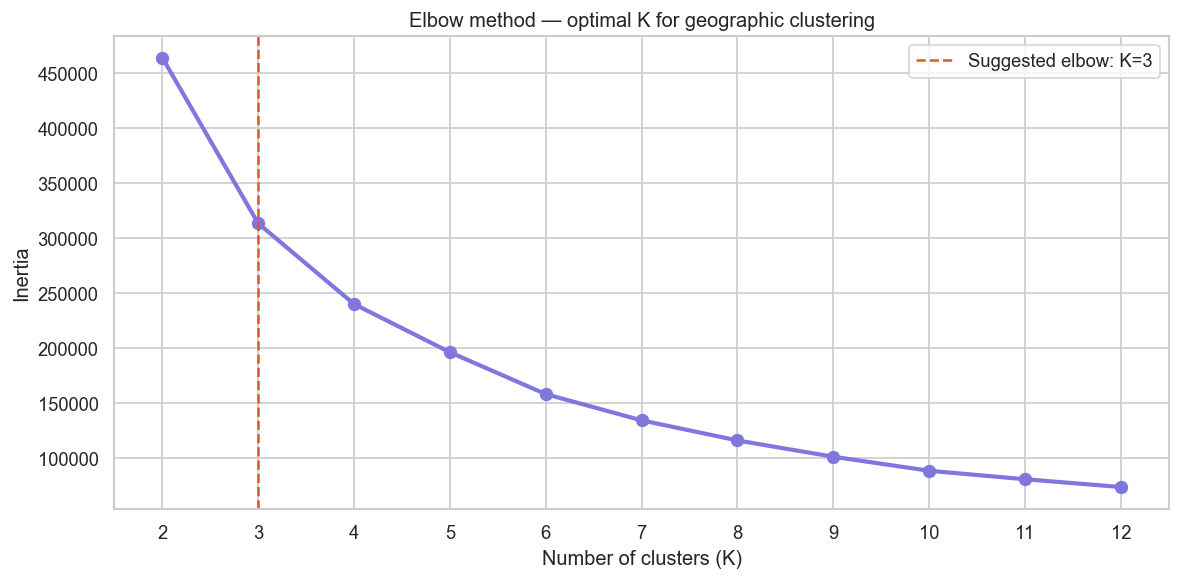


Suggested elbow at K = 3


In [8]:
print("Running elbow method (K = 2 to 12)... this takes ~2 minutes")

inertias = []
k_range = range(2, 13)

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(geo_scaled)
    inertias.append(km.inertia_)
    print(f"  K={k}  inertia={km.inertia_:,.0f}")

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(k_range, inertias, marker="o", color="#7F77DD", linewidth=2.5, markersize=7)
ax.set_xlabel("Number of clusters (K)")
ax.set_ylabel("Inertia")
ax.set_title("Elbow method — optimal K for geographic clustering")
ax.set_xticks(list(k_range))

diffs = np.diff(inertias)
diffs2 = np.diff(diffs)
elbow_k = list(k_range)[np.argmax(diffs2) + 1]
ax.axvline(elbow_k, color="#D85A30", linestyle="--",
           linewidth=1.5, label=f"Suggested elbow: K={elbow_k}")
ax.legend()

plt.tight_layout()
plt.savefig("notebooks/plots/clustering/01_elbow.png")
plt.show()
print(f"\nSuggested elbow at K = {elbow_k}")

In [9]:
# Algorithm 1: K-Means clustering

In [10]:
BEST_K = 8

with mlflow.start_run(run_name="KMeans_Geographic"):
    mlflow.log_param("algorithm", "KMeans")
    mlflow.log_param("n_clusters", BEST_K)
    mlflow.log_param("random_state", 42)
    mlflow.log_param("n_init", 10)
    mlflow.log_param("feature_set", "Latitude_Longitude")
    mlflow.log_param("sample_size", len(geo_scaled))

    print(f"Fitting K-Means with K={BEST_K}...")
    kmeans = KMeans(n_clusters=BEST_K, random_state=42, n_init=10)
    kmeans_labels = kmeans.fit_predict(geo_scaled)

    sil_km = silhouette_score(geo_scaled, kmeans_labels, sample_size=50_000, random_state=42)
    db_km  = davies_bouldin_score(geo_scaled, kmeans_labels)
    inertia_km = kmeans.inertia_

    mlflow.log_metric("silhouette_score", sil_km)
    mlflow.log_metric("davies_bouldin_score", db_km)
    mlflow.log_metric("inertia", inertia_km)
    mlflow.sklearn.log_model(kmeans, "kmeans_model")

    print(f"  Silhouette score : {sil_km:.4f}  (target > 0.5)")
    print(f"  Davies-Bouldin   : {db_km:.4f}  (lower is better)")
    print(f"  Inertia          : {inertia_km:,.0f}")

df["KMeans_Cluster"] = kmeans_labels

cluster_summary_km = df.groupby("KMeans_Cluster").agg(
    Crime_Count=("ID", "count"),
    Avg_Severity=("Crime_Severity_Score", "mean"),
    Arrest_Rate=("Arrest", "mean"),
    Lat_Center=("Latitude", "mean"),
    Lon_Center=("Longitude", "mean"),
    Top_Crime=("Primary Type", lambda x: x.value_counts().index[0])
).round(3)

print("\nK-Means cluster summary:")
print(cluster_summary_km)

pickle.dump(kmeans, open("src/models/kmeans_geo.pkl", "wb"))
cluster_summary_km.to_parquet("../data/kmeans_cluster_summary.parquet")
print("\nModel and summary saved.")

Fitting K-Means with K=8...


2026/03/24 10:31:15 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/03/24 10:31:16 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


  Silhouette score : 0.4006  (target > 0.5)
  Davies-Bouldin   : 0.8043  (lower is better)
  Inertia          : 116,368

K-Means cluster summary:
                Crime_Count  Avg_Severity  Arrest_Rate  Lat_Center  \
KMeans_Cluster                                                       
0                     56783         4.811        0.129      41.971   
1                     53646         5.128        0.158      41.747   
2                     90570         4.988        0.249      41.884   
3                     72726         5.145        0.181      41.787   
4                     47820         5.046        0.180      41.708   
5                     48201         4.911        0.160      41.932   
6                     84695         4.672        0.138      41.887   
7                     45559         5.004        0.158      41.782   

                Lon_Center Top_Crime  
KMeans_Cluster                        
0                  -87.678     THEFT  
1                  -87.576   BATTERY

In [11]:
#  K-Means visualization

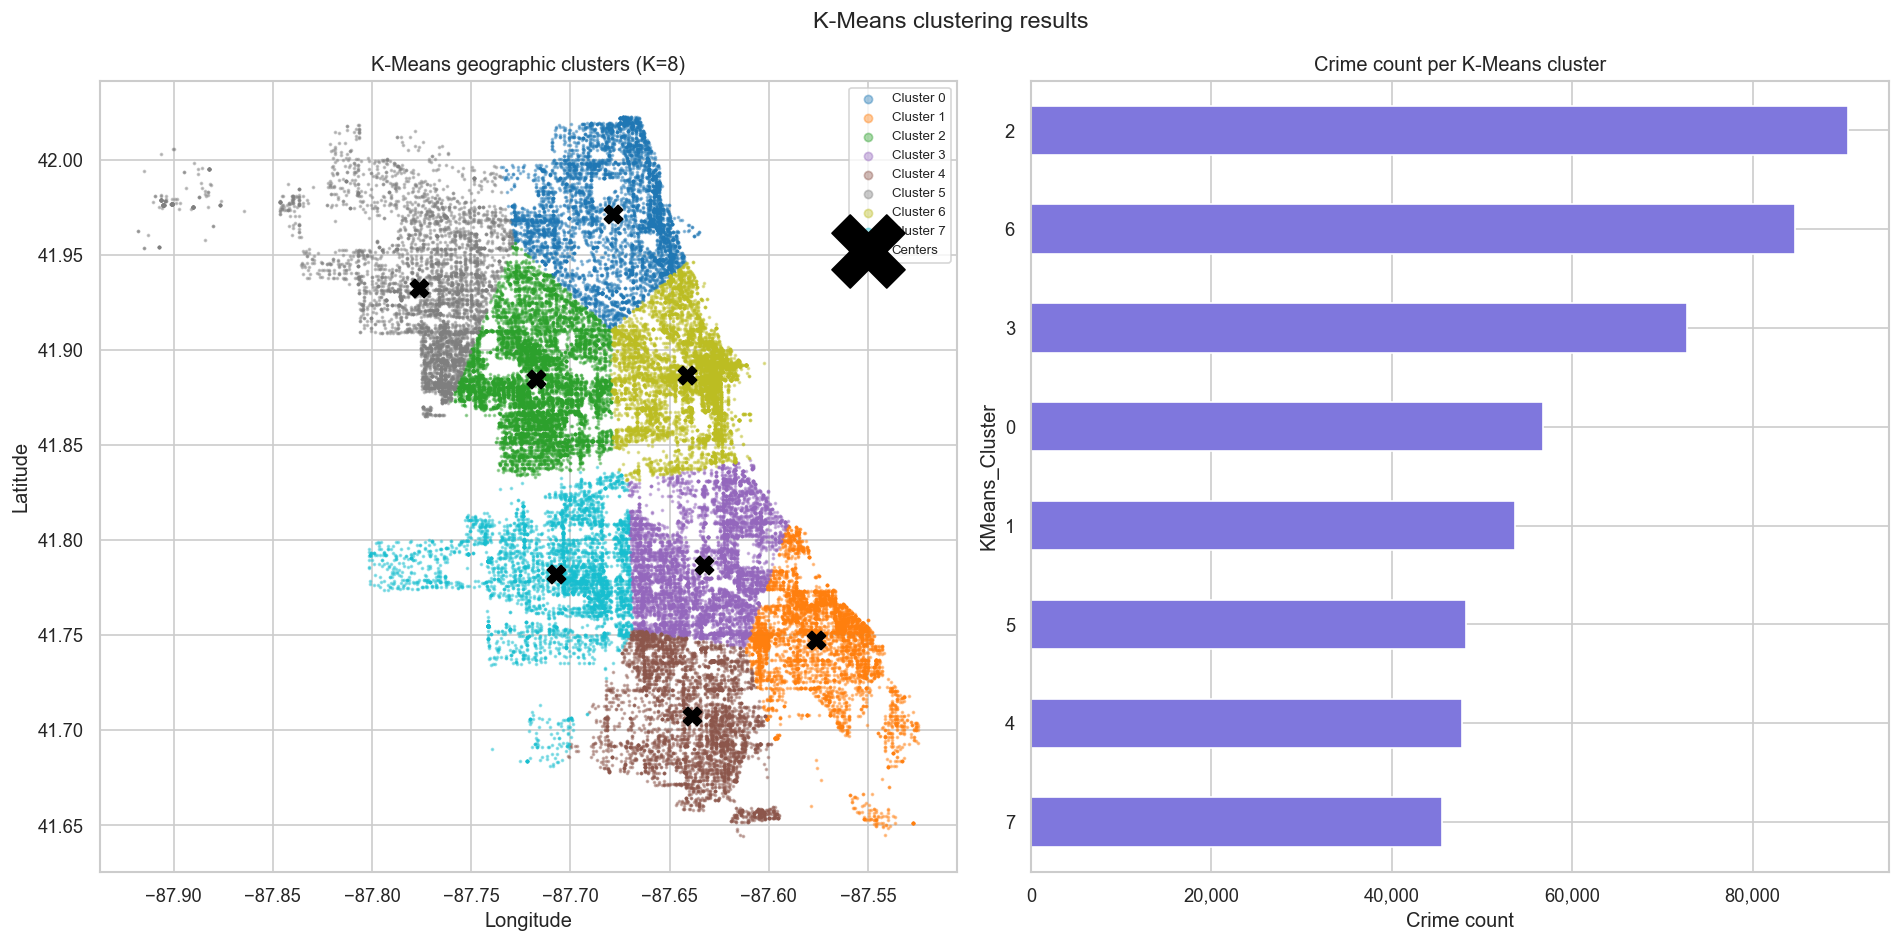

In [12]:
sample_idx = np.random.choice(len(geo_df), 50_000, replace=False)
geo_viz = geo_df.iloc[sample_idx].copy()
geo_viz["KMeans_Cluster"] = kmeans_labels[sample_idx]

colors = plt.cm.tab10(np.linspace(0, 1, BEST_K))

fig, axes = plt.subplots(1, 2, figsize=(16, 8))

for cluster_id in range(BEST_K):
    mask = geo_viz["KMeans_Cluster"] == cluster_id
    axes[0].scatter(
        geo_viz.loc[mask, "Longitude"],
        geo_viz.loc[mask, "Latitude"],
        c=[colors[cluster_id]], s=1.5, alpha=0.4,
        label=f"Cluster {cluster_id}"
    )

centers = scaler_geo.inverse_transform(kmeans.cluster_centers_)
axes[0].scatter(centers[:, 1], centers[:, 0],
                c="black", marker="X", s=120, zorder=5, label="Centers")
axes[0].set_title(f"K-Means geographic clusters (K={BEST_K})")
axes[0].set_xlabel("Longitude")
axes[0].set_ylabel("Latitude")
axes[0].legend(markerscale=4, fontsize=8)

cluster_summary_km["Crime_Count"].sort_values().plot(
    kind="barh", ax=axes[1], color="#7F77DD"
)
axes[1].set_title("Crime count per K-Means cluster")
axes[1].set_xlabel("Crime count")
axes[1].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))

plt.suptitle("K-Means clustering results", fontsize=14)
plt.tight_layout()
plt.savefig("notebooks/plots/clustering/02_kmeans.png")
plt.show()

In [13]:
# Algorithm 2: DBSCAN clustering

In [14]:
geo_sample_idx = np.random.choice(len(geo_scaled), 100_000, replace=False)
geo_scaled_sample = geo_scaled[geo_sample_idx]

EPS = 0.08
MIN_SAMPLES = 50

with mlflow.start_run(run_name="DBSCAN_Geographic"):
    mlflow.log_param("algorithm", "DBSCAN")
    mlflow.log_param("eps", EPS)
    mlflow.log_param("min_samples", MIN_SAMPLES)
    mlflow.log_param("feature_set", "Latitude_Longitude")
    mlflow.log_param("sample_size", len(geo_scaled_sample))

    print(f"Fitting DBSCAN (eps={EPS}, min_samples={MIN_SAMPLES})...")
    dbscan = DBSCAN(eps=EPS, min_samples=MIN_SAMPLES, n_jobs=-1)
    dbscan_labels = dbscan.fit_predict(geo_scaled_sample)

    n_clusters_db = len(set(dbscan_labels)) - (1 if -1 in dbscan_labels else 0)
    n_noise_db    = (dbscan_labels == -1).sum()
    noise_pct     = n_noise_db / len(dbscan_labels) * 100

    mlflow.log_metric("n_clusters_found", n_clusters_db)
    mlflow.log_metric("noise_points", int(n_noise_db))
    mlflow.log_metric("noise_pct", noise_pct)

    core_mask = dbscan_labels != -1
    if n_clusters_db > 1 and core_mask.sum() > 1000:
        sil_db = silhouette_score(
            geo_scaled_sample[core_mask],
            dbscan_labels[core_mask],
            sample_size=20_000, random_state=42
        )
        mlflow.log_metric("silhouette_score", sil_db)
        print(f"  Silhouette score (non-noise): {sil_db:.4f}")
    else:
        sil_db = None

    print(f"  Clusters found : {n_clusters_db}")
    print(f"  Noise points   : {n_noise_db:,} ({noise_pct:.1f}%)")

geo_sample_df = geo_df.iloc[geo_sample_idx].copy()
geo_sample_df["DBSCAN_Cluster"] = dbscan_labels

pickle.dump(dbscan, open("src/models/dbscan_geo.pkl", "wb"))
geo_sample_df.to_parquet("../data/dbscan_results.parquet")
print("DBSCAN model and results saved.")

Fitting DBSCAN (eps=0.08, min_samples=50)...
  Silhouette score (non-noise): -0.1353
  Clusters found : 10
  Noise points   : 1,117 (1.1%)
DBSCAN model and results saved.


In [15]:
# DBSCAN visualization

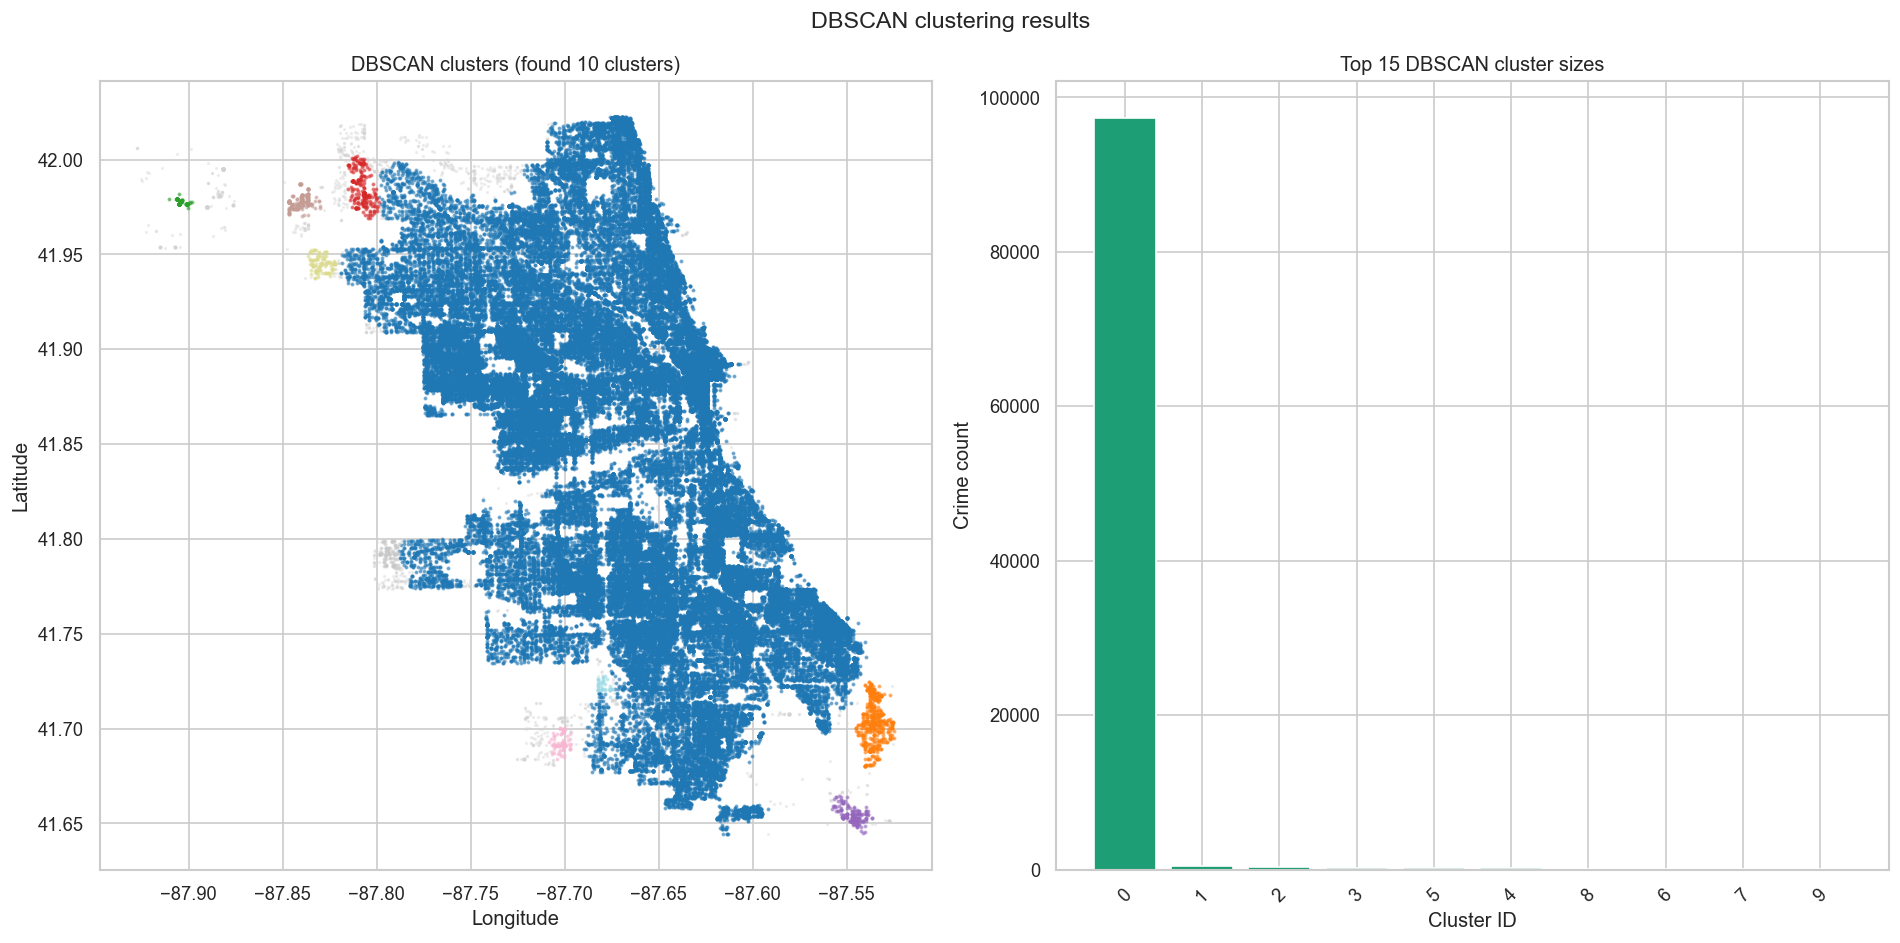


Noise filtered: 1,117 isolated incidents removed (1.1%)


In [16]:
fig, axes = plt.subplots(1, 2, figsize=(16, 8))

noise_mask    = geo_sample_df["DBSCAN_Cluster"] == -1
cluster_mask  = ~noise_mask

axes[0].scatter(
    geo_sample_df.loc[noise_mask, "Longitude"],
    geo_sample_df.loc[noise_mask, "Latitude"],
    c="lightgray", s=1, alpha=0.3, label="Noise"
)

unique_clusters = sorted(set(dbscan_labels[dbscan_labels != -1]))
cmap = plt.cm.tab20(np.linspace(0, 1, max(len(unique_clusters), 1)))
for i, cid in enumerate(unique_clusters[:20]):
    mask = geo_sample_df["DBSCAN_Cluster"] == cid
    axes[0].scatter(
        geo_sample_df.loc[mask, "Longitude"],
        geo_sample_df.loc[mask, "Latitude"],
        c=[cmap[i]], s=2, alpha=0.5, label=f"C{cid}"
    )

axes[0].set_title(f"DBSCAN clusters (found {n_clusters_db} clusters)")
axes[0].set_xlabel("Longitude")
axes[0].set_ylabel("Latitude")

cluster_sizes = geo_sample_df[cluster_mask]["DBSCAN_Cluster"].value_counts().head(15)
axes[1].bar(cluster_sizes.index.astype(str), cluster_sizes.values, color="#1D9E75")
axes[1].set_title("Top 15 DBSCAN cluster sizes")
axes[1].set_xlabel("Cluster ID")
axes[1].set_ylabel("Crime count")
axes[1].tick_params(axis="x", rotation=45)

plt.suptitle("DBSCAN clustering results", fontsize=14)
plt.tight_layout()
plt.savefig("notebooks/plots/clustering/03_dbscan.png")
plt.show()
print(f"\nNoise filtered: {n_noise_db:,} isolated incidents removed ({noise_pct:.1f}%)")

In [17]:
# Algorithm 3: Hierarchical clustering + dendrogram

In [18]:
HIER_SAMPLE = 20_000
hier_idx = np.random.choice(len(geo_scaled), HIER_SAMPLE, replace=False)
geo_hier  = geo_scaled[hier_idx]

N_HIER_CLUSTERS = 8

with mlflow.start_run(run_name="Hierarchical_Geographic"):
    mlflow.log_param("algorithm", "AgglomerativeClustering")
    mlflow.log_param("n_clusters", N_HIER_CLUSTERS)
    mlflow.log_param("linkage", "ward")
    mlflow.log_param("sample_size", HIER_SAMPLE)

    print(f"Fitting Hierarchical clustering (n={HIER_SAMPLE} sample)...")
    hier = AgglomerativeClustering(
        n_clusters=N_HIER_CLUSTERS, linkage="ward"
    )
    hier_labels = hier.fit_predict(geo_hier)

    sil_hier = silhouette_score(geo_hier, hier_labels, sample_size=10_000, random_state=42)
    db_hier  = davies_bouldin_score(geo_hier, hier_labels)

    mlflow.log_metric("silhouette_score", sil_hier)
    mlflow.log_metric("davies_bouldin_score", db_hier)

    print(f"  Silhouette score : {sil_hier:.4f}")
    print(f"  Davies-Bouldin   : {db_hier:.4f}")

geo_hier_df = geo_df.iloc[hier_idx].copy()
geo_hier_df["Hier_Cluster"] = hier_labels

pickle.dump(hier, open("src/models/hierarchical_geo.pkl", "wb"))
geo_hier_df.to_parquet("../data/hierarchical_results.parquet")
print("Hierarchical model and results saved.")

Fitting Hierarchical clustering (n=20000 sample)...
  Silhouette score : 0.3376
  Davies-Bouldin   : 0.8247
Hierarchical model and results saved.


In [19]:
# Dendrogram + geographic plot

Building dendrogram on 2,000-point subsample...


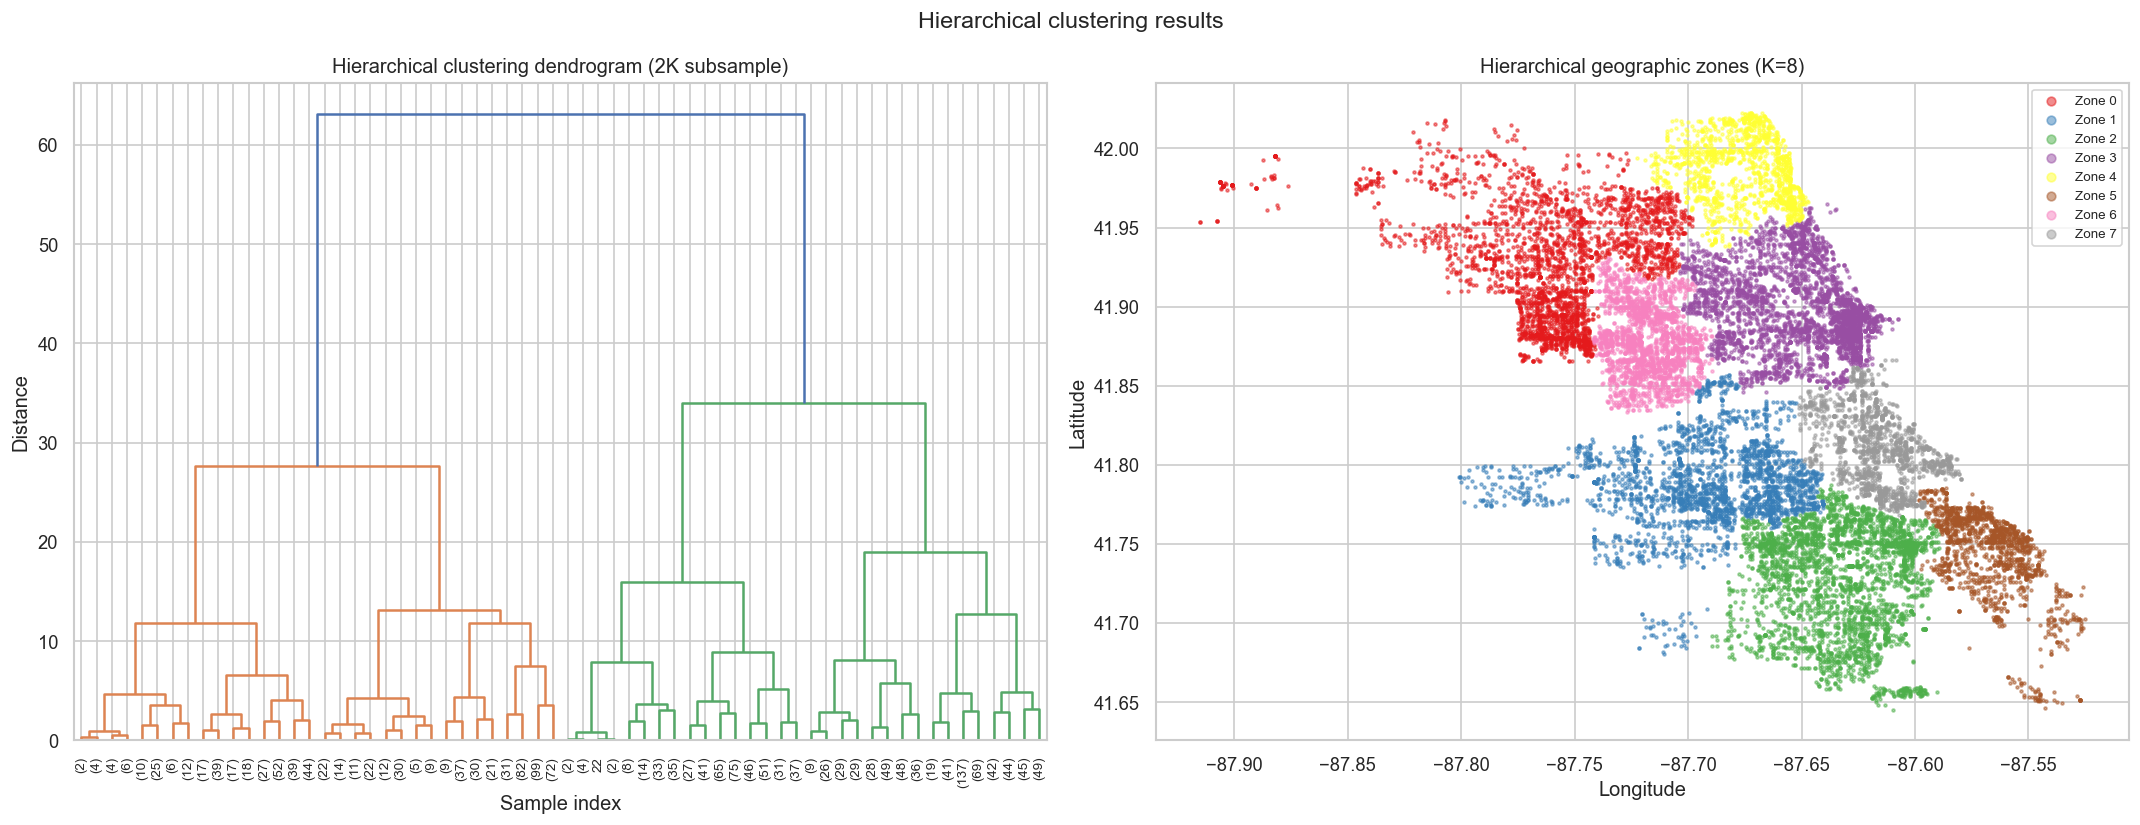

In [20]:
print("Building dendrogram on 2,000-point subsample...")
dend_idx    = np.random.choice(len(geo_hier), 2000, replace=False)
linkage_mat = linkage(geo_hier[dend_idx], method="ward")

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

dendrogram(
    linkage_mat, ax=axes[0],
    truncate_mode="level", p=5,
    leaf_rotation=90, leaf_font_size=8,
    color_threshold=0.7 * max(linkage_mat[:, 2])
)
axes[0].set_title("Hierarchical clustering dendrogram (2K subsample)")
axes[0].set_xlabel("Sample index")
axes[0].set_ylabel("Distance")

colors_h = plt.cm.Set1(np.linspace(0, 1, N_HIER_CLUSTERS))
for cid in range(N_HIER_CLUSTERS):
    mask = geo_hier_df["Hier_Cluster"] == cid
    axes[1].scatter(
        geo_hier_df.loc[mask, "Longitude"],
        geo_hier_df.loc[mask, "Latitude"],
        c=[colors_h[cid]], s=3, alpha=0.5, label=f"Zone {cid}"
    )
axes[1].set_title(f"Hierarchical geographic zones (K={N_HIER_CLUSTERS})")
axes[1].set_xlabel("Longitude")
axes[1].set_ylabel("Latitude")
axes[1].legend(markerscale=3, fontsize=8)

plt.suptitle("Hierarchical clustering results", fontsize=14)
plt.tight_layout()
plt.savefig("notebooks/plots/clustering/04_hierarchical.png")
plt.show()

In [21]:
# Algorithm comparison


GEOGRAPHIC CLUSTERING ALGORITHM COMPARISON
   Algorithm  Silhouette Score  Davies-Bouldin  Clusters Found                                 Notes
     K-Means            0.4006          0.8043               8                 Best for patrol zones
      DBSCAN           -0.1353             NaN              10 Finds natural hotspots, removes noise
Hierarchical            0.3376          0.8247               8                  Shows zone hierarchy


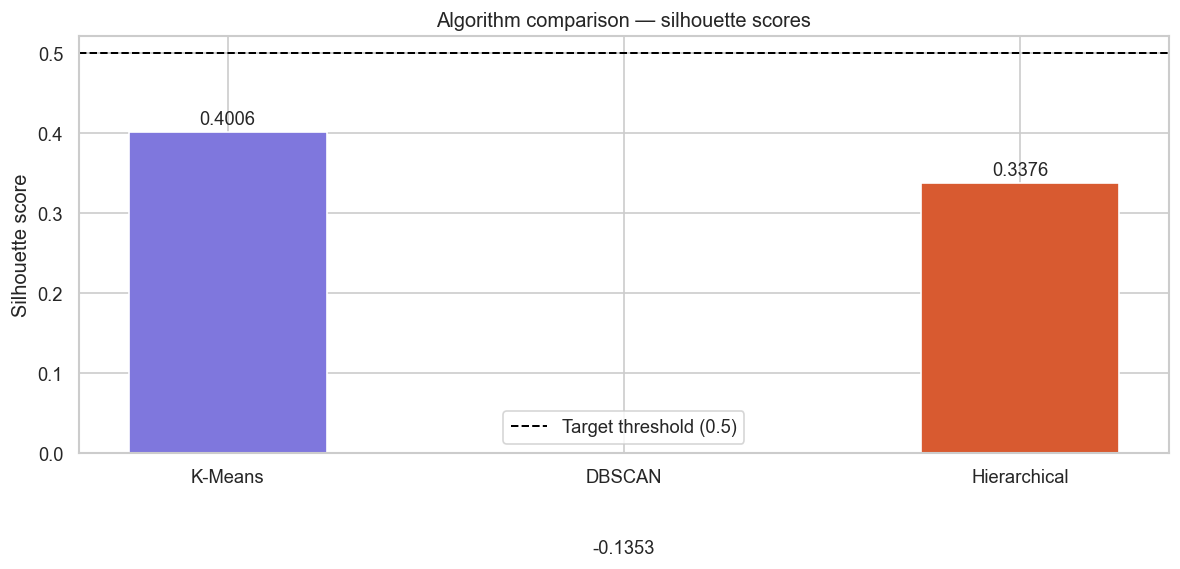


Best performing algorithm: K-Means


In [22]:
comparison = pd.DataFrame({
    "Algorithm": ["K-Means", "DBSCAN", "Hierarchical"],
    "Silhouette Score": [
        round(sil_km, 4),
        round(sil_db, 4) if sil_db else None,
        round(sil_hier, 4)
    ],
    "Davies-Bouldin": [
        round(db_km, 4),
        None,
        round(db_hier, 4)
    ],
    "Clusters Found": [BEST_K, n_clusters_db, N_HIER_CLUSTERS],
    "Notes": [
        "Best for patrol zones",
        "Finds natural hotspots, removes noise",
        "Shows zone hierarchy"
    ]
})

print("\n" + "=" * 70)
print("GEOGRAPHIC CLUSTERING ALGORITHM COMPARISON")
print("=" * 70)
print(comparison.to_string(index=False))

fig, ax = plt.subplots(figsize=(10, 5))
sil_scores = [sil_km, sil_db if sil_db else 0, sil_hier]
algos      = ["K-Means", "DBSCAN", "Hierarchical"]
bar_colors = ["#7F77DD", "#1D9E75", "#D85A30"]
bars = ax.bar(algos, sil_scores, color=bar_colors, width=0.5)
ax.axhline(0.5, color="black", linestyle="--",
           linewidth=1.2, label="Target threshold (0.5)")
ax.set_ylabel("Silhouette score")
ax.set_title("Algorithm comparison — silhouette scores")
ax.set_ylim(0, max(sil_scores) * 1.3)
ax.legend()

for bar, val in zip(bars, sil_scores):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.01,
            f"{val:.4f}", ha="center", fontsize=11)

plt.tight_layout()
plt.savefig("notebooks/plots/clustering/05_algorithm_comparison.png")
plt.show()

comparison.to_parquet("../data/clustering_comparison.parquet")
best_algo = algos[np.argmax(sil_scores)]
print(f"\nBest performing algorithm: {best_algo}")

In [23]:
# Temporal clustering

In [24]:
temporal_features = df[["Hour", "Month", "Is_Weekend",
                          "Crime_Severity_Score"]].copy()
temporal_features["Day_Num"] = pd.Categorical(
    df["Day_of_Week"],
    categories=["Monday","Tuesday","Wednesday",
                "Thursday","Friday","Saturday","Sunday"]
).codes

scaler_temp = StandardScaler()
temp_scaled = scaler_temp.fit_transform(temporal_features)

pickle.dump(scaler_temp, open("src/models/scaler_temporal.pkl", "wb"))

print("Running temporal elbow method...")
temp_inertias = []
for k in range(2, 9):
    km_t = KMeans(n_clusters=k, random_state=42, n_init=10)
    km_t.fit(temp_scaled)
    temp_inertias.append(km_t.inertia_)
    print(f"  K={k}  inertia={km_t.inertia_:,.0f}")

TEMP_K = 4

with mlflow.start_run(run_name="KMeans_Temporal"):
    mlflow.log_param("algorithm", "KMeans_Temporal")
    mlflow.log_param("n_clusters", TEMP_K)
    mlflow.log_param("features", "Hour,Month,Is_Weekend,Severity,DayNum")

    km_temp = KMeans(n_clusters=TEMP_K, random_state=42, n_init=10)
    temp_labels = km_temp.fit_predict(temp_scaled)

    sil_temp = silhouette_score(temp_scaled, temp_labels,
                                sample_size=50_000, random_state=42)
    mlflow.log_metric("silhouette_score", sil_temp)
    mlflow.log_metric("inertia", km_temp.inertia_)
    mlflow.sklearn.log_model(km_temp, "kmeans_temporal")

    print(f"\n  Temporal silhouette score: {sil_temp:.4f}")

df["Temporal_Cluster"] = temp_labels
pickle.dump(km_temp, open("src/models/kmeans_temporal.pkl", "wb"))
print("Temporal model saved.")

Running temporal elbow method...
  K=2  inertia=1,689,037
  K=3  inertia=1,386,087
  K=4  inertia=1,227,365
  K=5  inertia=1,098,453
  K=6  inertia=972,889
  K=7  inertia=885,046
  K=8  inertia=806,449


2026/03/24 10:34:44 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/03/24 10:34:44 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html



  Temporal silhouette score: 0.2513
Temporal model saved.


In [25]:
# Temporal cluster profiles

In [26]:
temporal_features["Temporal_Cluster"] = temp_labels
temporal_features["Primary_Type"] = df["Primary Type"].values
temporal_features["Hour_orig"] = df["Hour"].values
temporal_features["Day_of_Week"] = df["Day_of_Week"].values
temporal_features["Season"] = df["Season"].values

profile = temporal_features.groupby("Temporal_Cluster").agg(
    Count=("Hour_orig", "count"),
    Avg_Hour=("Hour_orig", "mean"),
    Avg_Severity=("Crime_Severity_Score", "mean"),
    Weekend_Rate=("Is_Weekend", "mean"),
    Top_Day=("Day_of_Week", lambda x: x.value_counts().index[0]),
    Top_Season=("Season", lambda x: x.value_counts().index[0]),
    Top_Crime=("Primary_Type", lambda x: x.value_counts().index[0])
).round(3)

cluster_names = {
    0: "Late-night crimes",
    1: "Morning incidents",
    2: "Afternoon peak",
    3: "Weekend patterns"
}
profile.index = [cluster_names.get(i, f"Pattern {i}")
                 for i in profile.index]

print("\nTemporal cluster profiles:")
print(profile.to_string())
profile.to_parquet("../data/temporal_cluster_profiles.parquet")


Temporal cluster profiles:
                    Count  Avg_Hour  Avg_Severity  Weekend_Rate   Top_Day Top_Season Top_Crime
Late-night crimes  143505    12.388         5.048           1.0  Saturday     Summer     THEFT
Morning incidents  106903    12.993         3.604           0.0    Friday       Fall     THEFT
Afternoon peak     108744    12.957         3.654           0.0    Friday     Spring     THEFT
Weekend patterns   140848    13.101         6.879           0.0    Friday     Summer   BATTERY


In [27]:
# Temporal visualizations

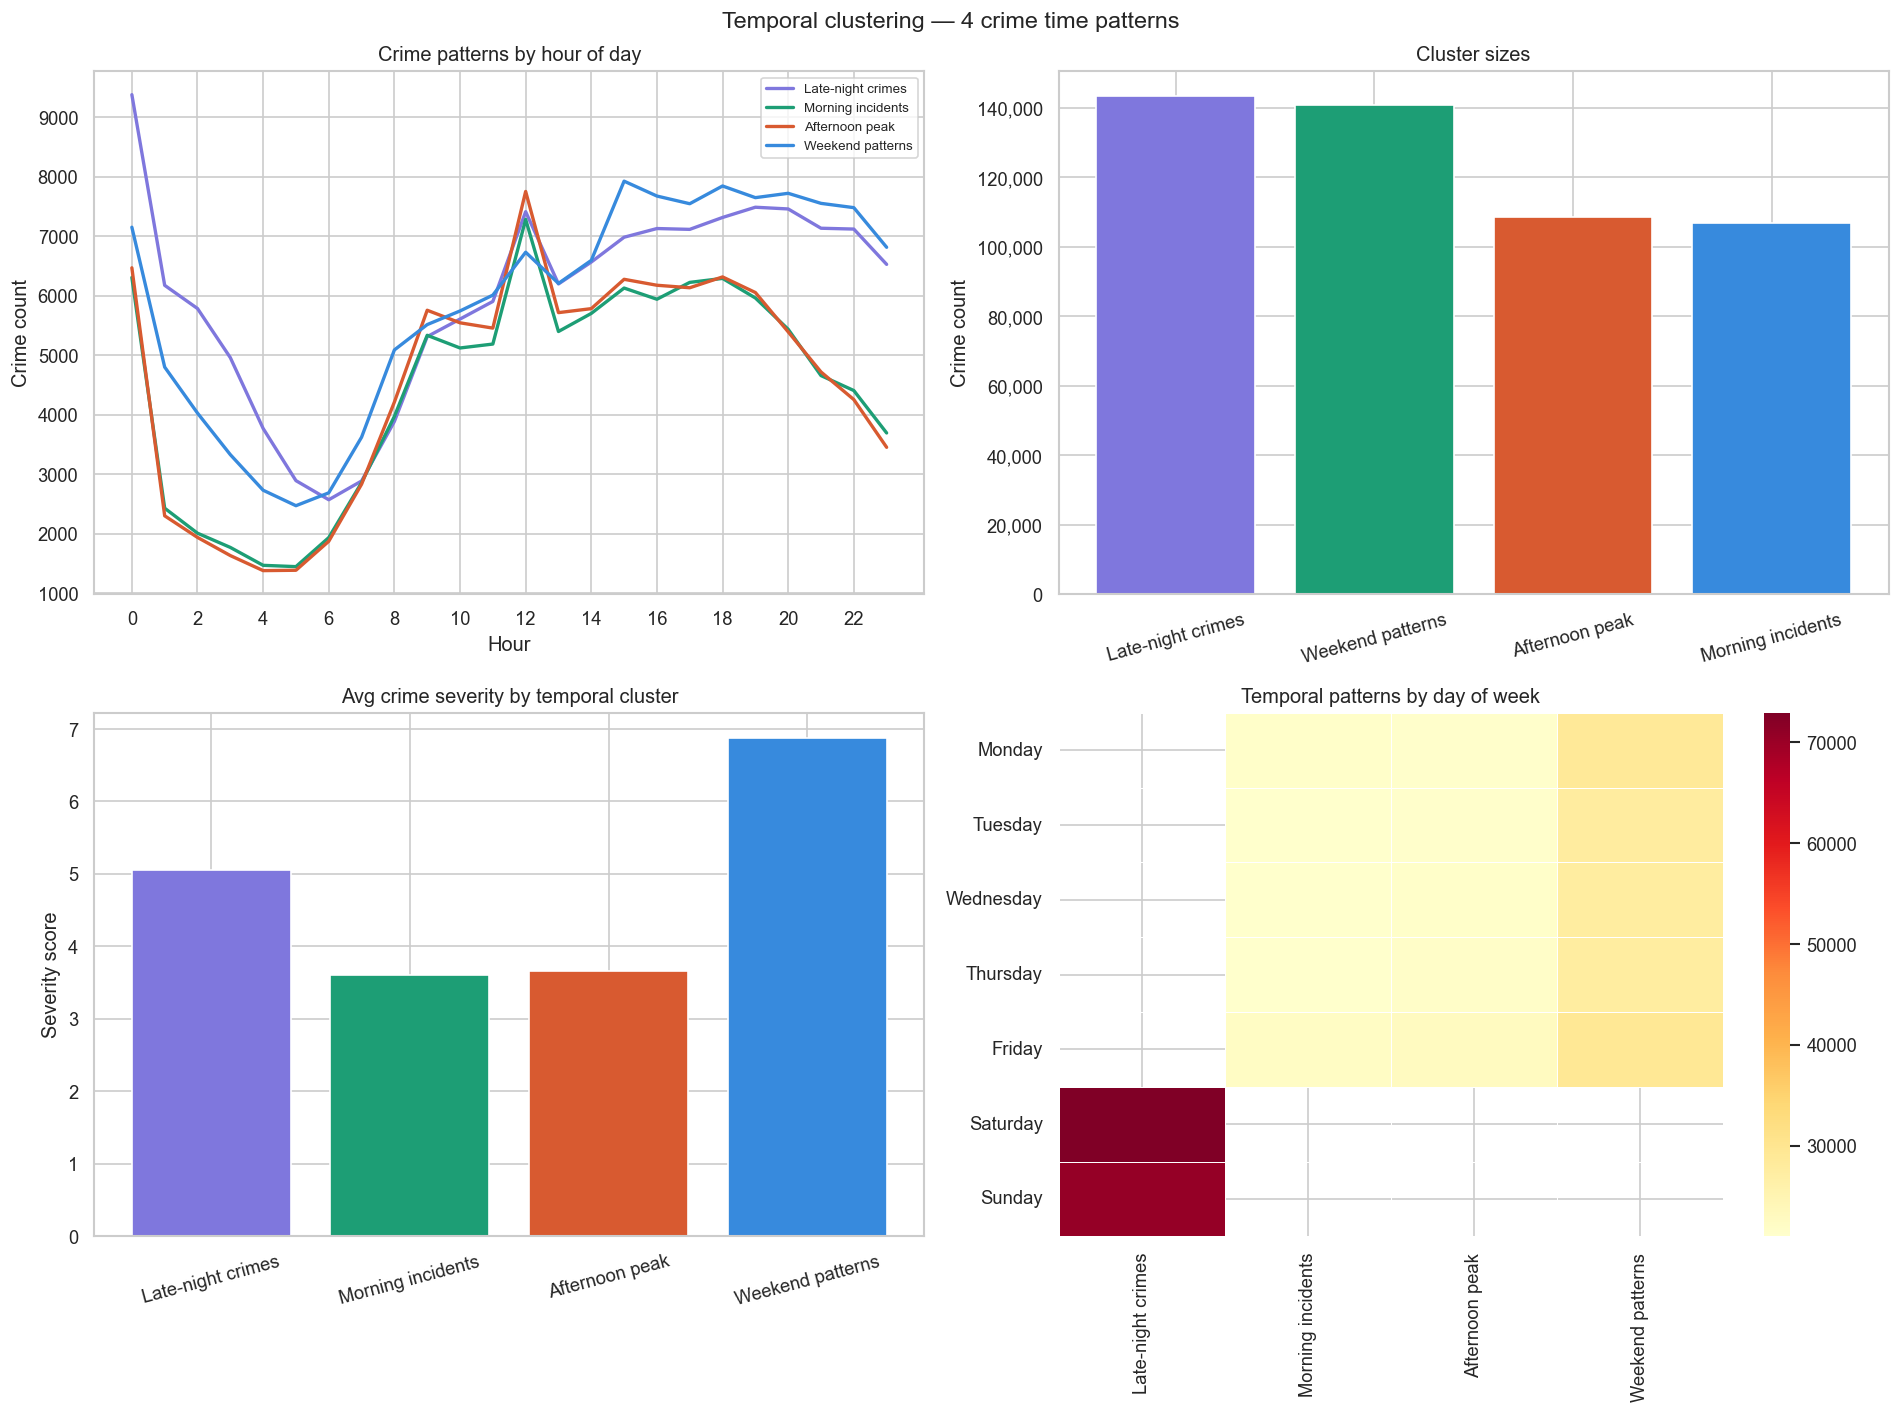

In [28]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

colors_t = ["#7F77DD", "#1D9E75", "#D85A30", "#378ADD"]

for i, (name, group) in enumerate(
    temporal_features.groupby("Temporal_Cluster")
):
    label = cluster_names.get(i, f"Pattern {i}")
    hour_dist = group["Hour_orig"].value_counts().sort_index()
    axes[0, 0].plot(hour_dist.index, hour_dist.values,
                    label=label, color=colors_t[i], linewidth=2)

axes[0, 0].set_title("Crime patterns by hour of day")
axes[0, 0].set_xlabel("Hour")
axes[0, 0].set_ylabel("Crime count")
axes[0, 0].legend(fontsize=8)
axes[0, 0].set_xticks(range(0, 24, 2))

cluster_size = temporal_features["Temporal_Cluster"].value_counts()
cluster_size.index = [cluster_names.get(i, f"P{i}") for i in cluster_size.index]
axes[0, 1].bar(cluster_size.index, cluster_size.values, color=colors_t)
axes[0, 1].set_title("Cluster sizes")
axes[0, 1].set_ylabel("Crime count")
axes[0, 1].tick_params(axis="x", rotation=15)
axes[0, 1].yaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, _: f"{int(x):,}")
)

severity_by_cluster = temporal_features.groupby(
    "Temporal_Cluster")["Crime_Severity_Score"].mean()
severity_by_cluster.index = [cluster_names.get(i, f"P{i}")
                              for i in severity_by_cluster.index]
axes[1, 0].bar(severity_by_cluster.index,
               severity_by_cluster.values, color=colors_t)
axes[1, 0].set_title("Avg crime severity by temporal cluster")
axes[1, 0].set_ylabel("Severity score")
axes[1, 0].tick_params(axis="x", rotation=15)

pivot_temp = temporal_features.pivot_table(
    index="Day_of_Week", columns="Temporal_Cluster",
    values="Hour_orig", aggfunc="count"
)
pivot_temp.index.name = None
pivot_temp.columns = [cluster_names.get(c, f"P{c}")
                      for c in pivot_temp.columns]
day_order = ["Monday","Tuesday","Wednesday","Thursday",
             "Friday","Saturday","Sunday"]
pivot_temp = pivot_temp.reindex(
    [d for d in day_order if d in pivot_temp.index]
)
sns.heatmap(pivot_temp, ax=axes[1, 1], cmap="YlOrRd",
            fmt=",", linewidths=0.3)
axes[1, 1].set_title("Temporal patterns by day of week")
axes[1, 1].set_xlabel("")

plt.suptitle("Temporal clustering — 4 crime time patterns", fontsize=14)
plt.tight_layout()
plt.savefig("notebooks/plots/clustering/06_temporal_patterns.png")
plt.show()

In [29]:
# Save final dataset & MLflow summary

In [30]:
df.to_parquet("../data/crimes_clustered.parquet", index=False)

print("=" * 65)
print("CLUSTERING COMPLETE — Final summary")
print("=" * 65)
print(f"  Records processed    : {len(df):,}")
print(f"  Geographic clusters  : K-Means={BEST_K}, DBSCAN={n_clusters_db}, Hier={N_HIER_CLUSTERS}")
print(f"  Temporal clusters    : {TEMP_K}")
print()
print("  Silhouette scores:")
print(f"    K-Means       : {sil_km:.4f}")
print(f"    DBSCAN        : {sil_db:.4f}" if sil_db else "    DBSCAN        : N/A")
print(f"    Hierarchical  : {sil_hier:.4f}")
print(f"    Temporal      : {sil_temp:.4f}")
print()
print("  Saved files:")
print("    ../data/crimes_clustered.parquet")
print("    ../data/kmeans_cluster_summary.parquet")
print("    ../data/dbscan_results.parquet")
print("    ../data/hierarchical_results.parquet")
print("    ../data/temporal_cluster_profiles.parquet")
print("    ../data/clustering_comparison.parquet")
print("    src/models/*.pkl  (5 model files)")
print()
print("  MLflow runs logged: 4")
print("    View UI → run: mlflow ui")
print("=" * 65)
print("Ready for Step 5 — Dimensionality Reduction.")

CLUSTERING COMPLETE — Final summary
  Records processed    : 500,000
  Geographic clusters  : K-Means=8, DBSCAN=10, Hier=8
  Temporal clusters    : 4

  Silhouette scores:
    K-Means       : 0.4006
    DBSCAN        : -0.1353
    Hierarchical  : 0.3376
    Temporal      : 0.2513

  Saved files:
    ../data/crimes_clustered.parquet
    ../data/kmeans_cluster_summary.parquet
    ../data/dbscan_results.parquet
    ../data/hierarchical_results.parquet
    ../data/temporal_cluster_profiles.parquet
    ../data/clustering_comparison.parquet
    src/models/*.pkl  (5 model files)

  MLflow runs logged: 4
    View UI → run: mlflow ui
Ready for Step 5 — Dimensionality Reduction.
